# PCA 2 — Digital Access Index




### Principal Component Analysis of Digital Access Across Bangladesh

This analysis applies Principal Component Analysis (PCA) to examine patterns of digital access across the 64 districts of Bangladesh.

The analysis focuses on indicators related to:

* Mobile phone access
* Internet access
* Financial account ownership
* Mobile banking account ownership

The objective is to determine whether these indicators contain overlapping information and whether their variation across districts can be represented using a smaller number of underlying dimensions.

### Research Question

**Can digital access across Bangladesh's 64 districts be represented by a smaller number of underlying dimensions?**

## Loading the dataset and the necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("housing_census_cleaned.csv")

### Selection of Digital-Access Indicators

The Housing Census dataset contains several variables related to digital access. These include indicators for mobile phone use, internet use, financial account ownership, and mobile banking.

Many of these variables are further divided by sex, age group, and rural–urban location. Including all of these variables would introduce substantial redundancy because several variables measure closely related aspects of the same underlying characteristic.

Therefore, the PCA focuses on selected overall indicators that provide broad measures of digital access at the district level.

The selected indicators are:

•	Mobile Phone (5+ years)

•	Mobile Phone (15+ years)

•	Internet (5+ years)

•	Internet (15+ years)

•	Financial Account

•	Mobile Banking Account


The selected indicators are combined into a separate analytical dataframe.

The division and district names are retained only for identification and interpretation. They are not included as variables in the PCA itself.

In [3]:
digital_pca = pd.DataFrame({
    "Division": df["division"],
    "District": df["district"],

    "Mobile Phone (5+ years)": df["_mobile_phone_total_5year"],
    "Mobile Phone (15+ years)": df["_mobile_phone_total_15_year"],

    "Internet (5+ years)": df["_inernet_total_5year"],
    "Internet (15+ years)": df["_inernet_total_15_year"],

    "Financial Account": df["_have_financial_account_overall"],
    "Mobile Banking Account": df["_mobile_bank_account_overall"]
})

print(
    digital_pca[
        [
            "Division",
            "District",
            "Mobile Phone (5+ years)",
            "Mobile Phone (15+ years)",
            "Internet (5+ years)",
            "Internet (15+ years)",
            "Financial Account",
            "Mobile Banking Account"
        ]
    ].to_string(index=False)
)

  Division        District  Mobile Phone (5+ years)  Mobile Phone (15+ years)  Internet (5+ years)  Internet (15+ years)  Financial Account  Mobile Banking Account
  Barishal         Barguna                    57.69                     71.39                24.37                 29.12              23.91                   45.23
    Khulna        Bagerhat                    57.46                     70.15                23.97                 28.58              25.84                   40.40
  Barishal        Barishal                    57.73                     72.49                26.37                 32.44              26.29                   42.03
  Barishal           Bhola                    51.80                     67.59                21.41                 26.36              23.16                   35.81
  Barishal       Jhalokati                    59.09                     73.88                24.56                 29.83              27.29                   45.07
Chattogram      

### Descriptive Statistics

Descriptive statistics are examined to understand the distribution of the selected digital-access indicators across the 64 districts.

The analysis considers the mean, standard deviation, minimum, maximum, and quartiles of each indicator.

In [4]:
digital_pca.describe()

,Mobile Phone (5+ years),Mobile Phone (15+ years),Internet (5+ years),Internet (15+ years),Financial Account,Mobile Banking Account
count,64.000000,64.000000,64.00000,64.000000,64.000000,64.000000
mean,54.206094,67.962813,27.21375,32.819375,24.337656,38.534219
std,4.591610,4.822102,7.87250,9.441074,4.047664,4.998865
min,42.670000,57.030000,15.16000,18.450000,12.580000,26.430000
25%,51.050000,65.007500,21.35250,26.190000,22.992500,35.240000
50%,53.935000,67.610000,25.38000,30.435000,24.865000,37.935000
75%,56.782500,71.397500,32.09250,37.695000,26.985000,41.775000
max,71.160000,84.690000,52.98000,60.970000,34.630000,51.350000


In [5]:
digital_pca.isnull().sum()

Division                    0
District                    0
Mobile Phone (5+ years)     0
Mobile Phone (15+ years)    0
Internet (5+ years)         0
Internet (15+ years)        0
Financial Account           0
Mobile Banking Account      0
dtype: int64

### Correlation Matrix

Before applying PCA, the correlations between the selected digital-access indicators are examined.

PCA is particularly useful when several variables contain overlapping information. Therefore, the correlation matrix provides an initial indication of whether different aspects of digital access follow related patterns across Bangladesh's districts.

The correlation matrix is calculated as:

Correlation Matrix = (1 / (n − 1)) × Xᵀ × X

where:

* X is the standardized data matrix.
* Xᵀ is the transpose of X.
* n is the number of districts.
* Xᵀ × X represents the matrix multiplication of the transpose of X and X.

The correlation structure will also help interpret the principal components after PCA is performed.

In [6]:
features = [
    "Mobile Phone (5+ years)",
    "Mobile Phone (15+ years)",
    "Internet (5+ years)",
    "Internet (15+ years)",
    "Financial Account",
    "Mobile Banking Account"
]

correlation_matrix = digital_pca[features].corr()

correlation_matrix

,Mobile Phone (5+ years),Mobile Phone (15+ years),Internet (5+ years),Internet (15+ years),Financial Account,Mobile Banking Account
Mobile Phone (5+ years),1.000000,0.924222,0.619237,0.553666,0.690760,0.580180
Mobile Phone (15+ years),0.924222,1.000000,0.745733,0.721217,0.599309,0.390434
Internet (5+ years),0.619237,0.745733,1.000000,0.992294,0.465655,-0.096947
Internet (15+ years),0.553666,0.721217,0.992294,1.000000,0.405820,-0.161454
Financial Account,0.690760,0.599309,0.465655,0.405820,1.000000,0.477260
Mobile Banking Account,0.580180,0.390434,-0.096947,-0.161454,0.477260,1.000000


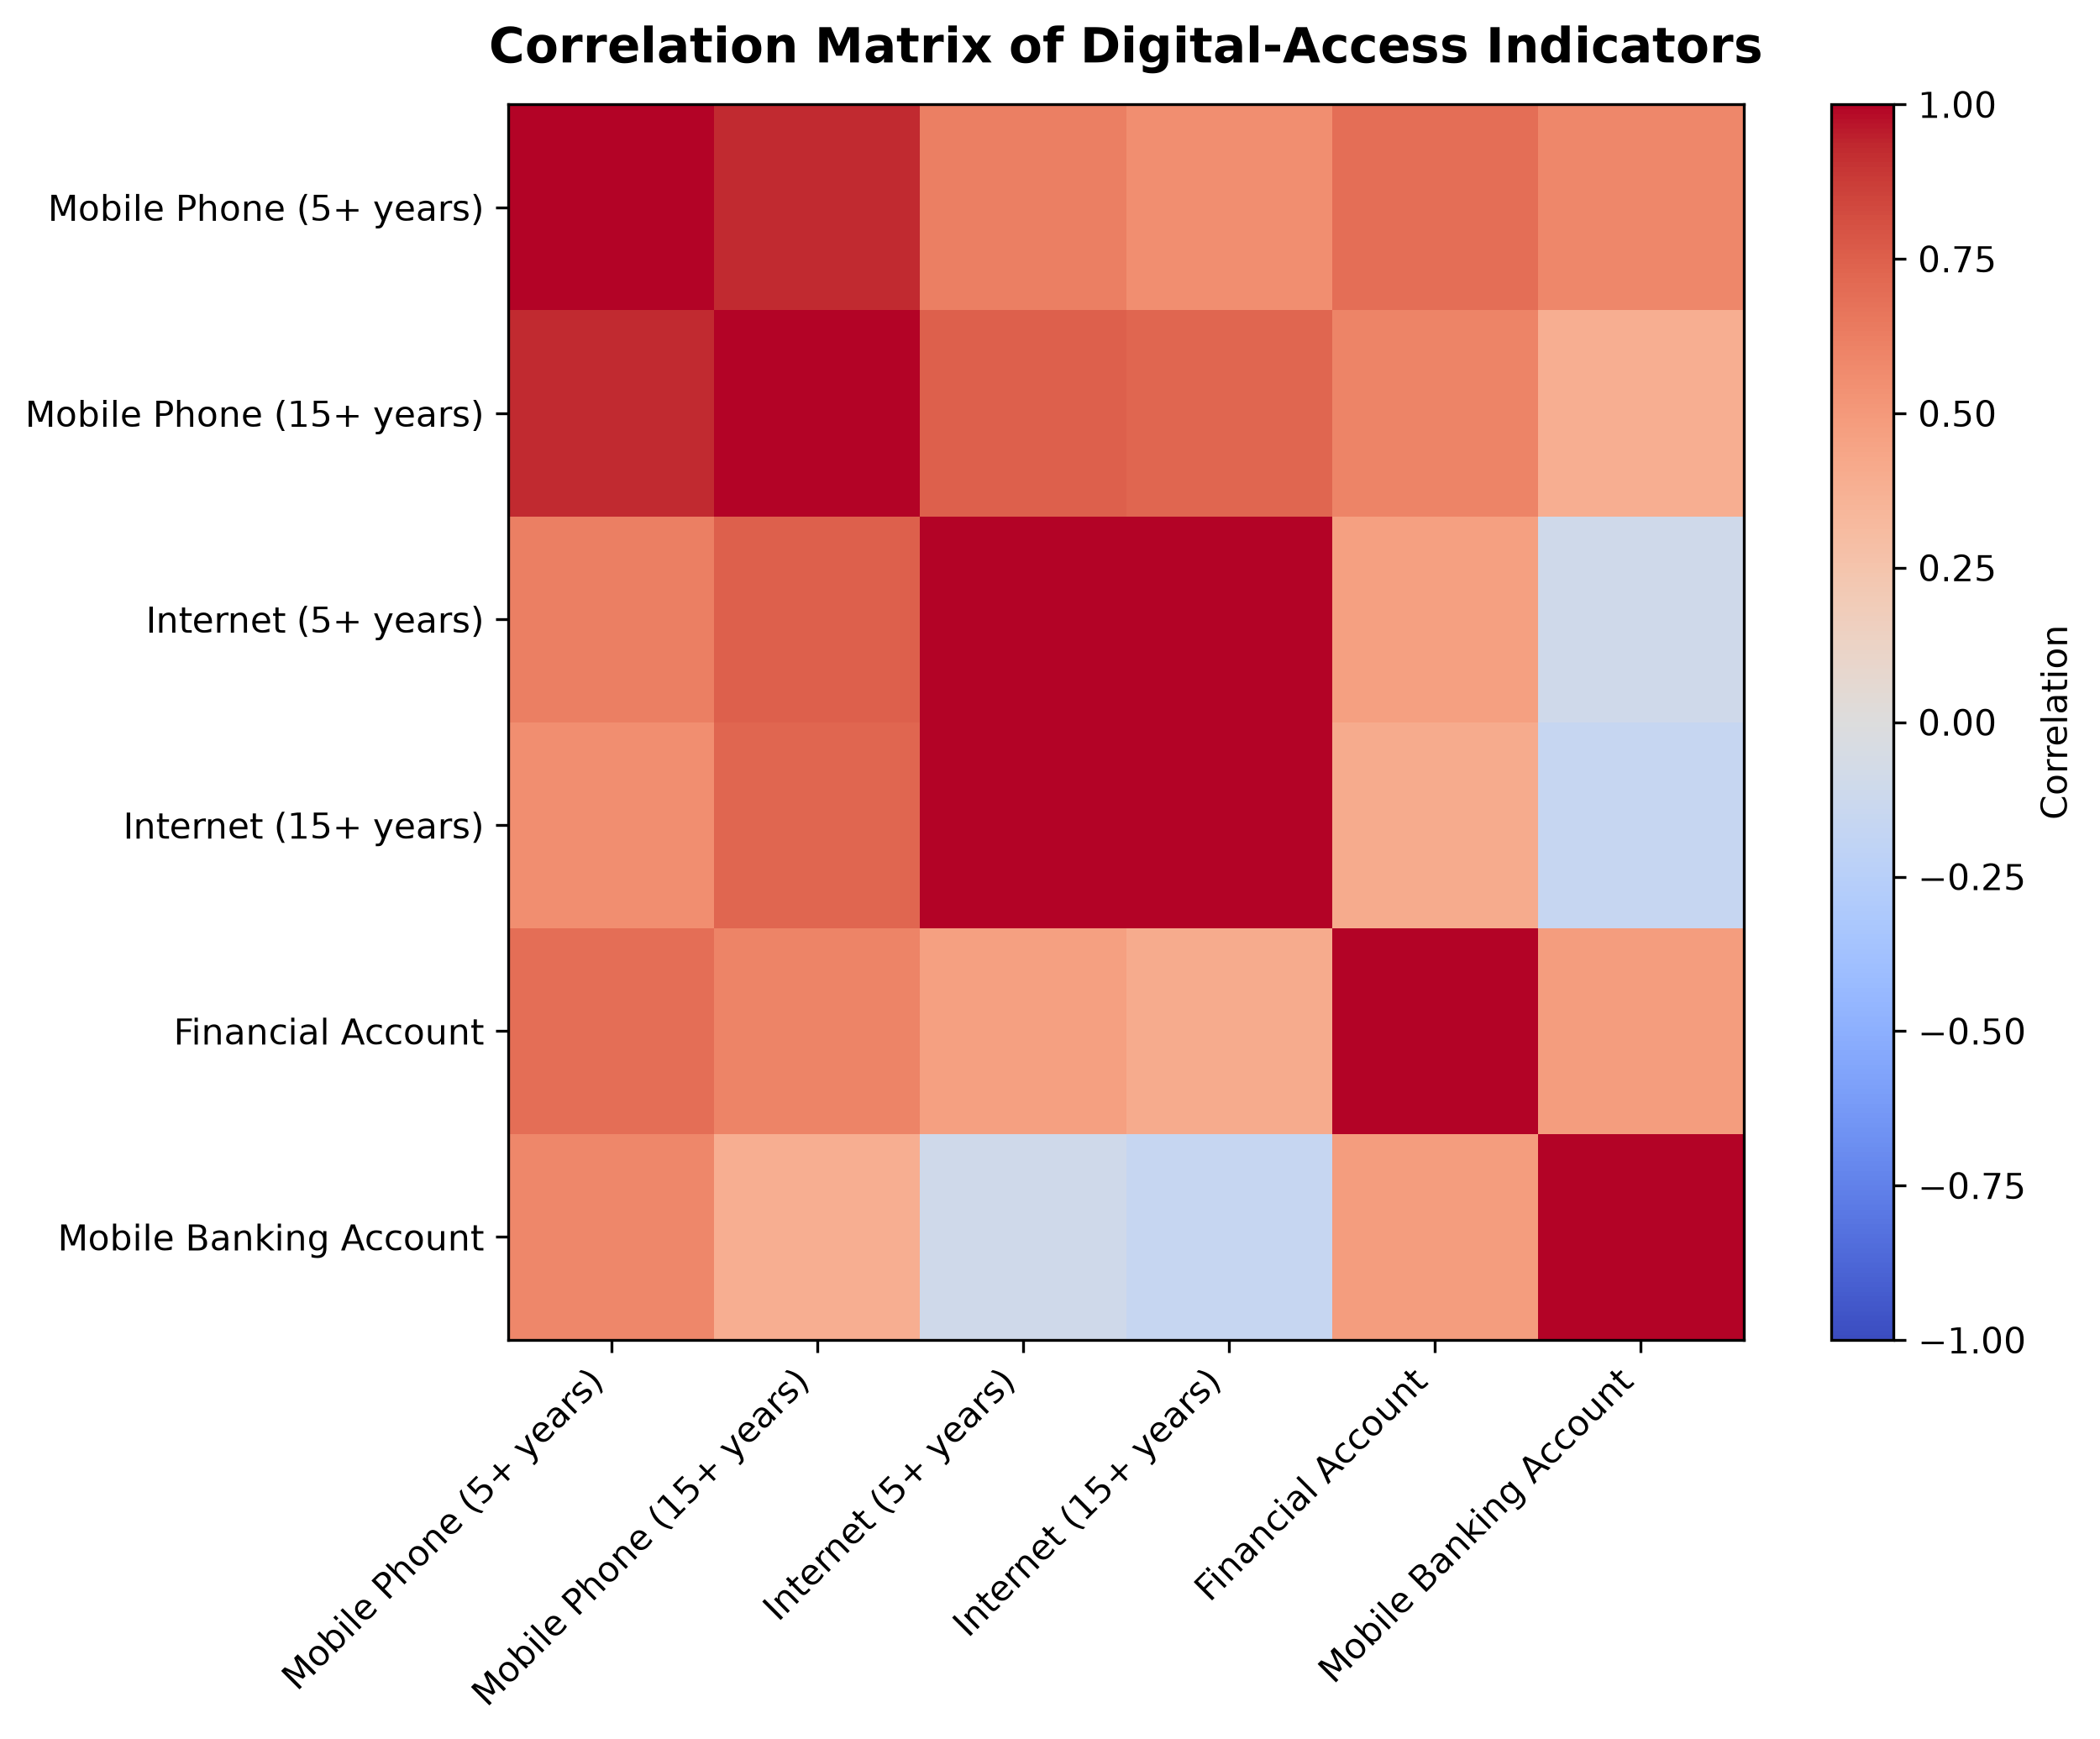

In [ ]:
plt.figure(figsize=(9, 7), dpi=300)

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(features)),
    features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(features)),
    features
)

plt.colorbar(label="Correlation")

plt.title(
    "Correlation Matrix of Digital-Access Indicators",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.tight_layout()

plt.savefig(
    "Correlation Matrix of Digital Access Indicators.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Standardization

The selected digital-access indicators are standardized before performing PCA.


For each observation (i) and variable (j), the standardized value is calculated as:

Standardized Value = (Original Value − Mean of the Variable) / Standard Deviation of the Variable

where:

* Original Value is the observed value for a particular district and variable.
* Mean of the Variable is the average value of that variable across all districts.
* Standard Deviation of the Variable measures the variability of that variable across all districts.

Standardization gives each variable a mean of approximately zero and a standard deviation of one.

This prevents variables with larger numerical scales or greater variability from dominating the PCA.

In [8]:
scaler = StandardScaler()

Z = pd.DataFrame(
    scaler.fit_transform(digital_pca[features]),
    columns=features
)

Z.insert(0, "District", digital_pca["District"].values)
Z.insert(0, "Division", digital_pca["Division"].values)

Z.head()

,Division,District,Mobile Phone (5+ years),Mobile Phone (15+ years),Internet (5+ years),Internet (15+ years),Financial Account,Mobile Banking Account
0,Barishal,Barguna,0.764753,0.716343,-0.364081,-0.394936,-0.106490,1.350049
1,Khulna,Bagerhat,0.714266,0.457161,-0.415293,-0.452585,0.374097,0.376192
2,Barishal,Barishal,0.773533,0.946263,-0.108024,-0.040501,0.486151,0.704843
3,Barishal,Bhola,-0.528162,-0.077924,-0.743046,-0.689587,-0.293247,-0.549276
4,Barishal,Jhalokati,1.072067,1.236798,-0.339756,-0.319138,0.735161,1.317789


In [9]:
Z[features].mean()

Mobile Phone (5+ years)    -1.762479e-15
Mobile Phone (15+ years)   -2.525757e-15
Internet (5+ years)        -1.665335e-16
Internet (15+ years)       -8.326673e-17
Financial Account          -4.857226e-16
Mobile Banking Account     -1.942890e-16
dtype: float64

In [10]:
Z[features].std()

Mobile Phone (5+ years)     1.007905
Mobile Phone (15+ years)    1.007905
Internet (5+ years)         1.007905
Internet (15+ years)        1.007905
Financial Account           1.007905
Mobile Banking Account      1.007905
dtype: float64

### Principal Component Analysis

PCA is applied to the standardized digital-access indicators.The PCA decomposes the standardized correlation structure into a set of orthogonal principal components. 

Mathematically, PCA is based on the eigenvalue equation:

Correlation Matrix × Eigenvector = Eigenvalue × Eigenvector

In simple notation:

R × v = λ × v

where:

* R is the correlation matrix of the six standardized variables.
* λ (lambda) is an eigenvalue.
* v (v) is the corresponding eigenvector.

The eigenvalues measure the amount of variance explained by the principal components, while the eigenvectors determine the directions of those components.

The first principal component corresponds to the direction of maximum variance in the standardized data. Each subsequent component explains the maximum remaining variance while remaining orthogonal to the preceding components.


### Eigenvalues and Explained variance 



The eigenvalues indicate how much of the total standardized variance is explained by each principal component.

The proportion of variance explained by the k-th principal component is calculated as:

Explained Variance = Eigenvalue of the Component / Sum of All Eigenvalues

Since there are five original variables, the total number of eigenvalues is five.

The cumulative explained variance is then calculated by adding the explained variance of the principal components successively.

This is used to determine how many principal components are needed to represent a substantial proportion of the information contained in the original five-dimensional dataset.

In [15]:
pca = PCA()

principal_components = pca.fit_transform(Z[features])

eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

explained_df = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(eigenvalues))
    ],
    "Eigenvalue": eigenvalues,
    "Explained Variance (%)": explained_ratio * 100,
    "Cumulative Variance (%)": np.cumsum(explained_ratio) * 100
})

explained_df

,Principal Component,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,PC1,3.872338,63.530548,63.530548
1,PC2,1.576198,25.859501,89.390049
2,PC3,0.438979,7.201998,96.592047
3,PC4,0.157117,2.577698,99.169745
4,PC5,0.049714,0.815612,99.985357
5,PC6,0.000893,0.014643,100.000000


### Principal Component Loadings

The PCA loadings describe the relationship between the original digital-access indicators and each principal component.

The loading matrix is derived from the eigenvectors of the correlation matrix. A larger absolute loading indicates a stronger association between the corresponding digital-access indicator and the principal component.

The signs of the loadings indicate the direction of the relationship, while their magnitudes indicate the strength of the association.

The loading matrix is used to interpret the underlying patterns represented by each principal component and to identify which digital-access indicators contribute most strongly to each dimension.

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[
        f"PC{i+1}"
        for i in range(pca.n_components_)
    ]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
Mobile Phone (5+ years),0.470105,0.232347,-0.256039,-0.382532,0.682992,0.215989
Mobile Phone (15+ years),0.484393,0.038285,-0.359390,-0.414550,-0.653621,-0.188849
Internet (5+ years),0.435214,-0.405085,0.018327,0.356042,0.257408,-0.673153
Internet (15+ years),0.414736,-0.455526,-0.010218,0.367771,-0.143862,0.681494
Financial Account,0.382985,0.267977,0.869308,-0.125115,-0.100655,0.005353
Mobile Banking Account,0.190445,0.707913,-0.221688,0.635722,-0.095994,-0.009373


### Scree Plot

The scree plot displays the eigenvalue associated with each principal component.

It provides a visual indication of how much information is retained by successive components and helps identify components that contribute relatively little additional variance.

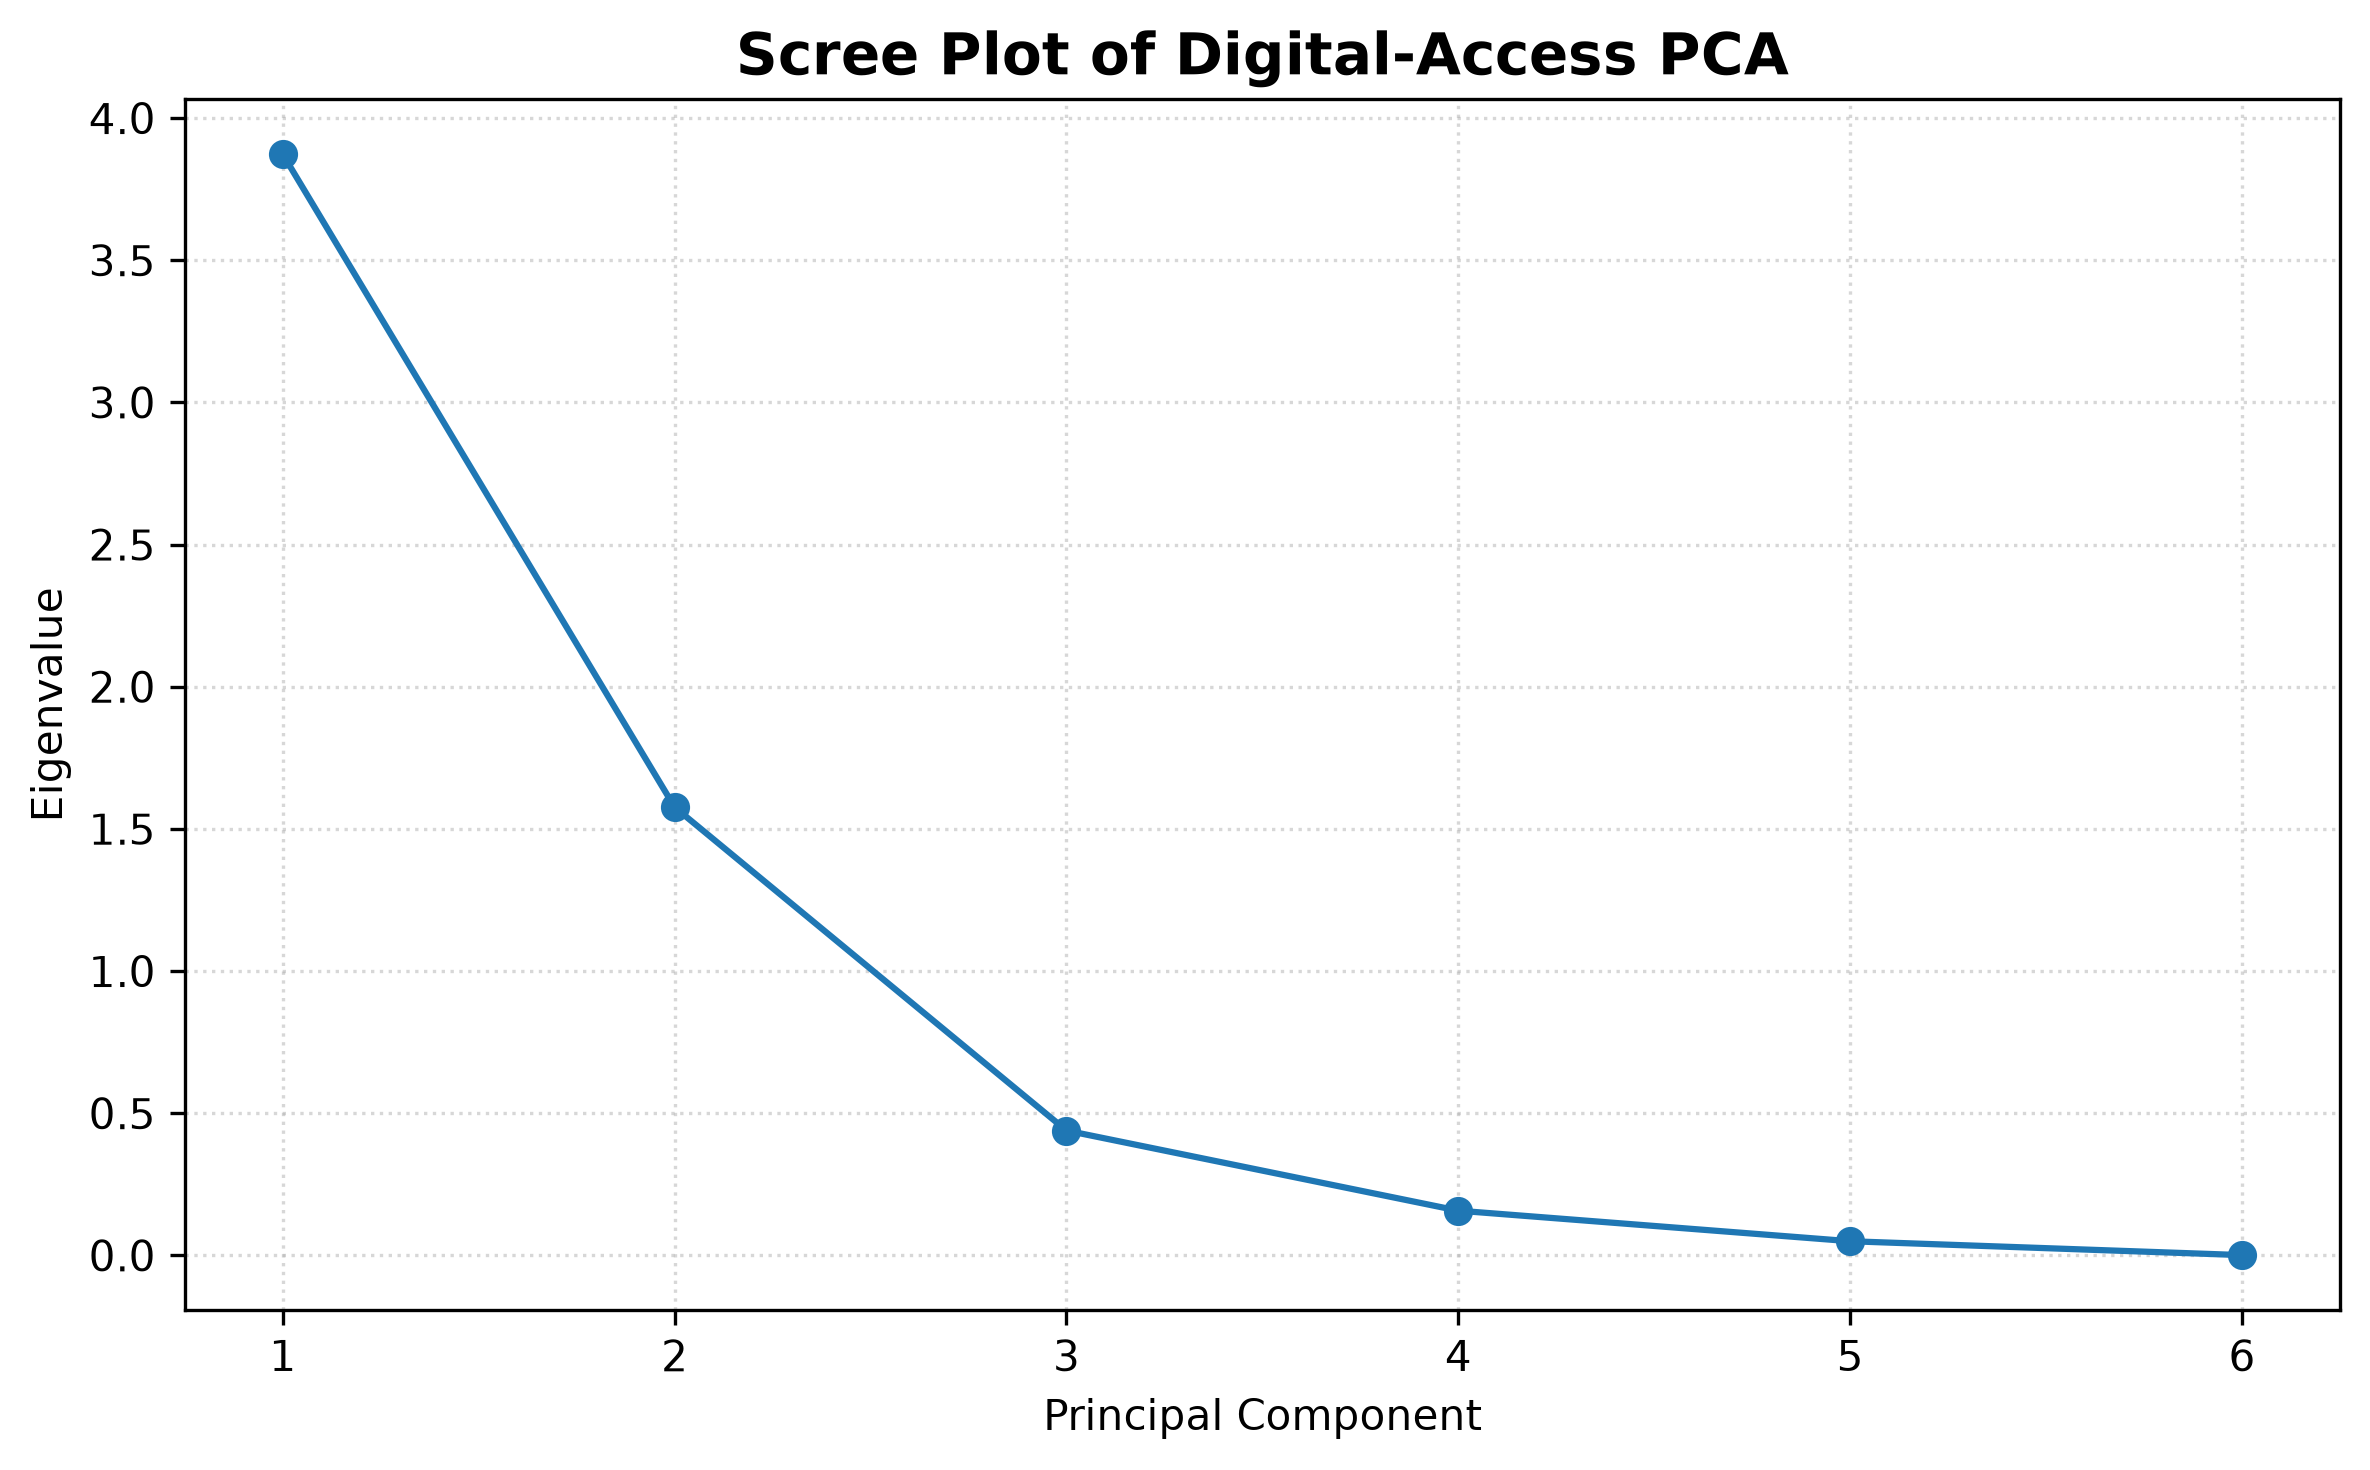

In [ ]:
plt.figure(figsize=(8, 5), dpi=300)

plt.plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")

plt.title(
    "Scree Plot of Digital-Access PCA",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(eigenvalues) + 1))

plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()

plt.show()

### Districts in Principal Component Space

The principal component scores are used to examine the relative position of the 64 districts in the reduced-dimensional space.

The PC1–PC2 scatter plot provides a visual representation of similarities and differences in digital-access patterns among districts.

Districts located close to one another have similar combinations of standardized digital-access indicators, while districts located farther apart have more distinct digital-access profiles.

In [16]:
scores = pd.DataFrame(
    principal_components,
    columns=[
        f"PC{i+1}"
        for i in range(principal_components.shape[1])
    ]
)

scores.insert(0, "District", Z["District"].values)
scores.insert(0, "Division", Z["Division"].values)


print(
    scores[
        [
            "Division",
            "District",
            "PC1",
            "PC2",
            "PC3",
            "PC4",
            "PC5",
            "PC6"
        ]
    ].to_string(index=False)
)

  Division        District       PC1       PC2       PC3       PC4       PC5       PC6
  Barishal         Barguna  0.600584  1.459680 -0.847753  0.007202 -0.101675 -0.007390
    Khulna        Bagerhat  0.403698  0.924413 -0.108357 -0.584707  0.073471  0.037537
  Barishal        Barishal  1.078617  0.907408 -0.273338 -0.354272 -0.228754  0.029485
  Barishal           Bhola -1.112335  0.021998  0.023509 -0.596320 -0.319614 -0.065549
  Barishal       Jhalokati  1.355377  1.709333 -0.375007 -0.415385 -0.318225  0.000788
Chattogram       Bandarban -1.321590 -0.459343  0.293317 -0.154523 -0.390727 -0.011172
  Barishal      Patuakhali -0.039159  1.059079 -0.320341 -0.819240 -0.221257  0.003941
  Barishal        Pirojpur  0.868021  1.348272 -0.753712 -0.262263 -0.211719  0.010574
Chattogram    Brahmanbaria  0.415992 -2.621067  0.409533  0.665215 -0.368752 -0.059317
Chattogram        Chandpur  1.891221 -0.457754 -0.332758  0.785864 -0.279031 -0.002314
  Rajshahi          Bogura  0.527340  0.981

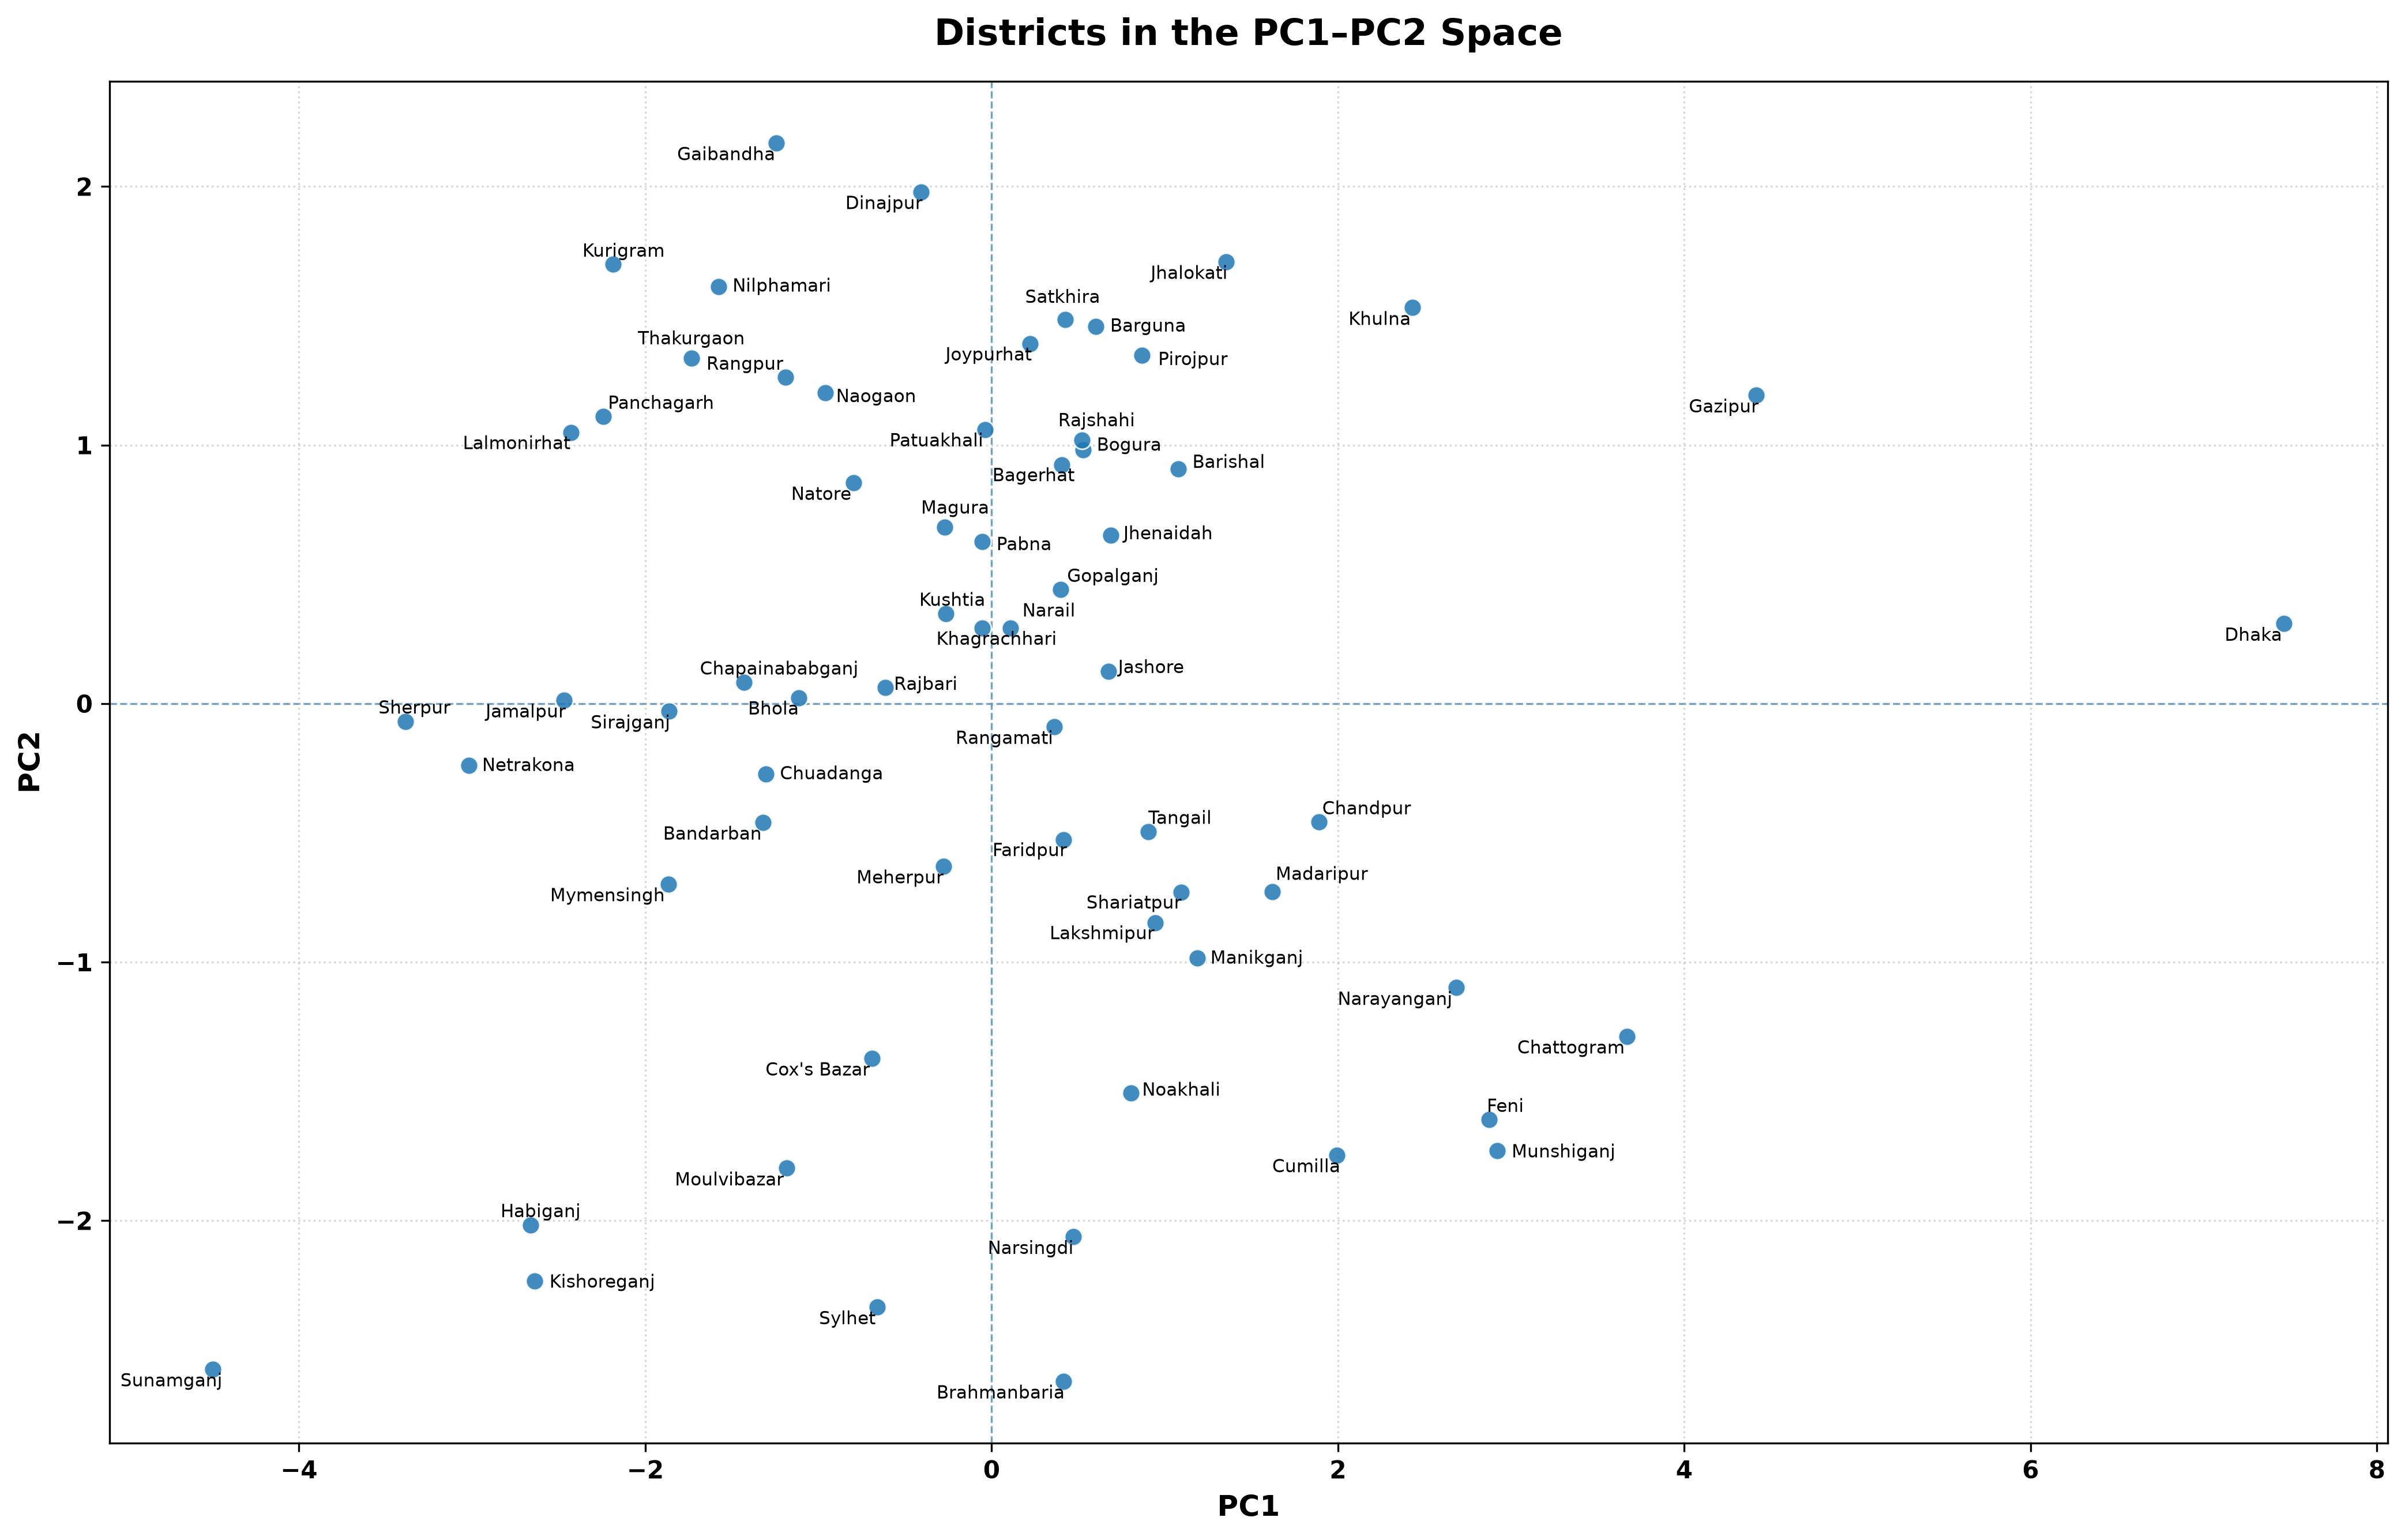

In [20]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 9), dpi=300)

ax.scatter(
    scores["PC1"],
    scores["PC2"],
    s=55,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.7,
    zorder=3
)

texts = []

for i, district in enumerate(scores["District"]):
    texts.append(
        ax.text(
            scores["PC1"].iloc[i],
            scores["PC2"].iloc[i],
            district,
            fontsize=7.5,
            ha="center",
            va="center"
        )
    )


adjust_text(
    texts,
    ax=ax,
    expand_text=(1.2, 1.3),
    expand_points=(1.2, 1.3),
    force_text=(0.5, 0.7),
    force_points=(0.3, 0.4),
    ensure_inside_axes=True
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8,
    alpha=0.7,
    zorder=1
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=0.8,
    alpha=0.7,
    zorder=1
)


ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
    zorder=0
)


ax.set_xlabel(
    "PC1",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "PC2",
    fontsize=12,
    fontweight="bold"
)


ax.set_title(
    "Districts in the PC1–PC2 Space",
    fontsize=15,
    fontweight="bold",
    pad=15
)


ax.tick_params(
    axis="both",
    labelsize=10
)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

plt.tight_layout()
plt.savefig("PC2.png",dpi=300)
plt.show()

### PCA Interpretation and Findings

### Correlation Analysis

The correlation matrix shows that several of the selected digital-access indicators are strongly positively related across Bangladesh's 64 districts.

The strongest correlations are observed between:

* **Internet (5+ years) and Internet (15+ years):** (r = 0.992)
* **Mobile Phone (5+ years) and Mobile Phone (15+ years):** (r = 0.924)
* **Mobile Phone (15+ years) and Internet (5+ years):** (r = 0.746)
* **Mobile Phone (5+ years) and Internet (5+ years):** (r = 0.619)
* **Mobile Phone (5+ years) and Financial Account:** (r = 0.691)

These relatively strong positive correlations indicate that districts with higher levels of access to one digital service tend to have higher levels of access to several other digital services.

The two internet indicators are particularly highly correlated (r = 0.992), indicating that internet access among the 5+ and 15+ age groups follows almost identical patterns across districts. Similarly, the two mobile-phone indicators show a strong correlation (r = 0.924).

However, Mobile Banking Account shows a different pattern. Its correlation with Internet (5+ years) is slightly negative (r = −0.097), while its correlation with Internet (15+ years) is also negative (r = −0.161). This suggests that mobile banking access does not follow exactly the same district-level pattern as internet access.

Overall, the correlation structure indicates substantial overlap among several digital-access indicators while also suggesting the presence of distinct dimensions of digital access. This makes PCA appropriate for reducing the dimensionality of the six-variable dataset.



### Explained Variance

The eigenvalue analysis produces the following results:

| Principal Component | Eigenvalue | Explained Variance (%) | Cumulative Variance (%) |
| ------------------- | ---------: | ---------------------: | ----------------------: |
| PC1                 |     3.8723 |                  63.53 |                   63.53 |
| PC2                 |     1.5762 |                  25.86 |                   89.39 |
| PC3                 |     0.4390 |                   7.20 |                   96.59 |
| PC4                 |     0.1571 |                   2.58 |                   99.17 |
| PC5                 |     0.0497 |                   0.82 |                   99.99 |
| PC6                 |     0.0009 |                   0.01 |                  100.00 |

The first principal component (**PC1**) explains **63.53%** of the total variance, while the second principal component (**PC2**) explains a further **25.86%**.

Together, PC1 and PC2 explain approximately **89.39% of the total variation** in the six original digital-access indicators.

The remaining four components contribute relatively little additional information. PC3 explains 7.20%, while PC4, PC5, and PC6 explain only 2.58%, 0.82%, and 0.01%, respectively.

Both PC1 and PC2 have eigenvalues greater than 1, while all remaining components have eigenvalues below 1. This provides additional support for retaining the first two principal components.

Therefore, the six-dimensional digital-access structure can be represented effectively using only **two principal components**, while retaining approximately **89.39% of the total variation**.


### Interpretation of the Principal Components

### PC1

The loadings of PC1 are positive across all six digital-access indicators:

* Mobile Phone (5+ years): 0.470
* Mobile Phone (15+ years): 0.484
* Internet (5+ years): 0.435
* Internet (15+ years): 0.415
* Financial Account: 0.383
* Mobile Banking Account: 0.190

The relatively similar positive loadings across the indicators indicate that **PC1 represents an overall digital-access dimension**.

Districts with high positive PC1 scores tend to have relatively high levels of mobile-phone access, internet access, financial-account ownership, and mobile-banking access.

The strongest contributions to PC1 come from the two mobile-phone indicators, followed by the two internet indicators and financial-account ownership. Mobile Banking Account has a positive but comparatively smaller loading.

Therefore, PC1 can be interpreted as the **overall level of digital access across districts**.

### PC2

PC2 shows a substantially different loading structure from PC1.

The loadings are:

* Mobile Phone (5+ years): 0.232
* Mobile Phone (15+ years): 0.038
* Internet (5+ years): −0.405
* Internet (15+ years): −0.456
* Financial Account: 0.268
* Mobile Banking Account: 0.708

The strongest positive loading belongs to **Mobile Banking Account (0.708)**, followed by Financial Account (0.268) and Mobile Phone (5+ years) (0.232).

In contrast, both internet indicators have negative loadings, particularly Internet (15+ years) (−0.456) and Internet (5+ years) (−0.405).

This indicates that **PC2 distinguishes districts with relatively stronger mobile-banking and financial-account access from districts characterized by relatively stronger internet access**.

The relatively small loading of Mobile Phone (15+ years) (0.038) suggests that this indicator contributes little to the distinction represented by PC2.

Therefore, PC2 can be interpreted as a **digital-financial versus internet-access dimension**, with positive PC2 values associated more strongly with mobile banking and financial-account access, and negative PC2 values associated more strongly with internet access.

Unlike PC1, which represents a broad overall digital-access pattern, PC2 captures a more specific difference in the type of digital access observed across districts.


### District-Level Interpretation

The principal component scores allow the 64 districts to be compared according to the underlying digital-access patterns identified by the PCA.

### PC1

There is considerable variation in PC1 scores across the districts.

**Dhaka** has by far the highest PC1 score (**7.46**), followed by **Gazipur (4.41)** and **Chattogram (3.67)**. Other districts with relatively high PC1 scores include **Munshiganj (2.92)**, **Feni (2.87)**, **Narayanganj (2.68)**, and **Khulna (2.43)**.

Because PC1 represents the overall digital-access dimension, these high positive scores indicate that these districts tend to have relatively strong levels across several of the selected digital-access indicators.

At the opposite end, **Sunamganj** has the lowest PC1 score (**−4.50**), followed by **Sherpur (−3.39)**, **Netrakona (−3.02)**, **Habiganj (−2.66)**, **Kishoreganj (−2.64)**, and **Jamalpur (−2.47)**.

Their negative PC1 scores indicate relatively lower values across the combined digital-access structure represented by PC1.


### PC2

PC2 provides a different perspective on the digital-access patterns across the districts.

**Gaibandha** has the highest PC2 score (**2.17**), followed by **Dinajpur (1.98)**, **Jhalokati (1.71)**, **Kurigram (1.70)**, **Nilphamari (1.61)**, **Rangpur (1.26)**, and **Naogaon (1.20)**.

Because positive PC2 scores are associated more strongly with Mobile Banking Account and, to a lesser extent, Financial Account, these districts are positioned toward the mobile-banking and financial-access side of the second principal component.

In contrast, **Brahmanbaria** has the lowest PC2 score (**−2.62**), followed by **Sunamganj (−2.57)**, **Sylhet (−2.33)**, **Kishoreganj (−2.23)**, **Narsingdi (−2.06)**, **Habiganj (−2.02)**, **Moulvibazar (−1.80)**, and **Munshiganj (−1.73)**.

Because the internet indicators have strong negative loadings on PC2, districts with strongly negative PC2 scores are positioned more toward the internet-access side of this dimension.

For example, **Brahmanbaria** has a PC2 score of **−2.62**, while **Gaibandha** has a score of **2.17**. These districts therefore occupy opposite ends of the second digital-access dimension.

It is important to note that a positive or negative PC2 score does not simply indicate higher or lower overall digital access. Instead, PC2 distinguishes **different patterns or types of digital access**, particularly the contrast between mobile-banking/financial access and internet access.


### Key Findings

The PCA reveals several important findings about digital access across Bangladesh's 64 districts:

1. The six digital-access indicators contain substantial shared information, particularly the two internet indicators (r = 0.992) and the two mobile-phone indicators (r = 0.924).

2. **PC1 explains 63.53% of the total variance** and represents a broad **overall digital-access dimension**, with positive loadings across all six indicators.

3. **PC2 explains a further 25.86% of the total variance** and represents a distinct **digital-financial versus internet-access dimension**. Mobile Banking Account has the strongest positive loading, while both internet indicators have relatively strong negative loadings.

4. **PC1 and PC2 together explain 89.39% of the total variance**, indicating that the six original digital-access indicators can be represented effectively using only two principal components.

5. The district-level scores reveal substantial geographical variation in digital-access patterns. Dhaka, Gazipur, and Chattogram occupy particularly high positions on PC1, while Sunamganj, Sherpur, and Netrakona have strongly negative PC1 scores.

6. PC2 reveals a different pattern from PC1. Districts such as Gaibandha, Dinajpur, and Jhalokati are positioned toward the positive end of PC2, while Brahmanbaria, Sunamganj, and Sylhet are positioned toward the negative end.

Overall, PCA provides a mathematically efficient way to summarize the multidimensional structure of digital access across Bangladesh's districts. The results suggest that most of the variation in the six selected indicators can be captured by two underlying dimensions: **overall digital access (PC1)** and a **digital-financial versus internet-access dimension (PC2)**.